# Top 10 Products — Retail Sales (2009–10)

| | |
|---|---|
| **Task** | Identify the top 10 products by sales |
| **Objective** | Practice ranking and sorting |
| **Tools** | Pandas (the Excel method is explained at the end) |
| **Deliverables** | Top-10 table · Chart |
| **Dataset** | `Retail_2009-10.csv` |

### Roadmap
1. Load the cleaned, sale-lines-only data (the rule from the earlier tasks)
2. Learn how ranking and sorting work on a tiny example
3. Spot a trap: not every `StockCode` is a real product
4. Add up sales by product
5. Sort, rank, and handle ties properly
6. Build the Top 10 table
7. Chart it
8. Save the deliverables
9. Interview answers

> **How to run:** keep this notebook and `Retail_2009-10.csv` in the same folder, then run all cells top to bottom.
> Needs `pandas`, `matplotlib` and `openpyxl` (`pip install pandas matplotlib openpyxl`).

## What does "ranking and sorting" mean here?

**Sorting** puts rows in order (here, by sales, biggest first). **Ranking** gives each row a position number (1st, 2nd, 3rd...).
They sound the same but answer different questions:

- Sorting answers *"what order do these belong in?"*
- Ranking answers *"exactly which position is this row?"* — and that is where **ties** come in. If two products have the
  exact same sales, do they share a rank, or does one arbitrarily come first? Pandas' `.rank()` lets you choose.

## Step 0 — Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)

## Step 1 — Load the data and keep only real sales

This reuses the exact rule from the earlier Duplicate Record Check and Basic Sales Summary tasks, so the numbers agree
across all three notebooks:

- Read with `encoding="utf-8-sig"` (the file has a hidden BOM character) and read ID columns as **text**, not numbers.
- Remove exact duplicate rows (`drop_duplicates`).
- Keep only **sale lines**: `Quantity x Price` above zero, on a normal invoice (not a cancellation, which starts with `C`).

In [2]:
DATA_FILE  = "Retail_2009-10.csv"
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

raw = pd.read_csv(DATA_FILE, encoding="utf-8-sig",
                  dtype={"Invoice": str, "StockCode": str, "Customer ID": str})
df = raw.drop_duplicates(keep="first")                      # Task 1: remove exact duplicates
df["Sales"] = df["Quantity"] * df["Price"]

is_cancellation = df["Invoice"].str.startswith("C")
is_sale_line = (~is_cancellation) & (df["Sales"] > 0)
sales = df[is_sale_line].copy()

print(f"Raw rows              : {len(raw):,}")
print(f"After removing dupes   : {len(df):,}")
print(f"Sale lines (used here) : {len(sales):,}")
print(f"Distinct product codes : {sales['StockCode'].nunique():,}")

Raw rows              : 525,461
After removing dupes   : 518,596
Sale lines (used here) : 504,730
Distinct product codes : 4,251


## Step 2 — How ranking and ties work (tiny example)

Before ranking real products, see what Pandas does with a small made-up table that has a **tie** (two products with the
same sales).

In [3]:
toy = pd.DataFrame({
    "Product": ["Mug", "Lamp", "Candle", "Vase", "Tray"],
    "Sales":   [500,    500,    300,      300,    100],
})

toy["Rank_min"]   = toy["Sales"].rank(method="min",   ascending=False).astype(int)
toy["Rank_dense"] = toy["Sales"].rank(method="dense", ascending=False).astype(int)
toy["Rank_first"] = toy["Sales"].rank(method="first", ascending=False).astype(int)
toy.sort_values("Sales", ascending=False)

,Product,Sales,Rank_min,Rank_dense,Rank_first
0,Mug,500,1,1,1
1,Lamp,500,1,1,2
2,Candle,300,3,2,3
3,Vase,300,3,2,4
4,Tray,100,5,3,5


Read the three tie-breaking methods:

| Method | Mug & Lamp (tied at 500) | Candle & Vase (tied at 300) | Tray | What it means |
|---|---|---|---|---|
| `"min"` | both get **1** | both get **3** | gets **5** | Ties share the *best* rank in the group; the next rank jumps (2 and 4 are skipped). This matches how people usually read a leaderboard: "joint 1st". |
| `"dense"` | both get **1** | both get **2** | gets **3** | Ties share a rank, but nothing is skipped afterwards. |
| `"first"` | one gets **1**, one gets **2** | one gets **3**, one gets **4** | gets **5** | No ties at all — whichever appears first in the data wins. Simple, but arbitrary and can hide that a tie exists. |

**This notebook uses `method="min"`**, because it is the most common convention (like Olympic medal tables: two golds means
the next place is bronze, not silver) and it never hides a genuine tie.

## Step 3 — A trap: not every `StockCode` is a real product

Before ranking, check what is actually in the `StockCode` column. Most codes are 5 digits (optionally with a letter), but
some are not.

In [4]:
looks_like_product = sales["StockCode"].str.match(r"^\d{5}[A-Za-z]?$")
odd_codes = sales.loc[~looks_like_product, "StockCode"].unique()

print(f"Non-standard codes found: {len(odd_codes)} (out of {sales['StockCode'].nunique():,} distinct codes)")

odd_summary = (sales[sales["StockCode"].isin(odd_codes)]
               .groupby("StockCode")
               .agg(Sales=("Sales", "sum"), Rows=("Sales", "size"),
                    Description=("Description", lambda x: x.mode().iat[0] if len(x.mode()) else None))
               .sort_values("Sales", ascending=False))
odd_summary.head(12)

Non-standard codes found: 43 (out of 4,251 distinct codes)


,Sales,Rows,Description
StockCode,,,
M,262577.36,550,Manual
DOT,116408.71,730,DOTCOM POSTAGE
POST,49477.54,759,POSTAGE
15056BL,31999.35,565,EDWARDIAN PARASOL BLACK
AMAZONFEE,20248.04,2,AMAZON FEE
ADJUST,8897.93,36,Adjustment by john on 26/01/2010 16
79323LP,8481.19,170,LIGHT PINK CHERRY LIGHTS
C2,6625.00,131,CARRIAGE
79323GR,3209.36,83,GREEN CHERRY LIGHTS


Most of these (`DCGS...`, `79323LP`, `SP1002`...) are real products with an unusual code — they are kept. But a handful are
**not products at all**:

In [5]:
NON_PRODUCT_CODES = {
    "M", "m",                 # Manual (a manual bookkeeping entry)
    "DOT", "POST", "C2",      # DOTCOM POSTAGE / POSTAGE / CARRIAGE - shipping charges
    "AMAZONFEE",              # Amazon Fee
    "ADJUST", "ADJUST2",      # Manual account adjustments
    "D",                      # Discount
    "BANK CHARGES",           # Bank Charges
    "S",                      # SAMPLES (given away, not sold)
    "TEST001", "TEST002",     # Literal test entries
    "gift_0001_10", "gift_0001_20", "gift_0001_30",   # Gift vouchers (not physical inventory)
    "gift_0001_40", "gift_0001_50", "gift_0001_70", "gift_0001_80",
}

excluded = sales[sales["StockCode"].isin(NON_PRODUCT_CODES)]
print(f"Rows excluded as non-product : {len(excluded):,}")
print(f"Sales value excluded         : {excluded['Sales'].sum():,.2f}")
excluded.groupby("StockCode").agg(Sales=("Sales", "sum"), Rows=("Sales", "size"),
                                   Description=("Description", "first")).sort_values("Sales", ascending=False)

Rows excluded as non-product : 2,300
Sales value excluded         : 467,115.42


,Sales,Rows,Description
StockCode,,,
M,262577.36,550,Manual
DOT,116408.71,730,DOTCOM POSTAGE
POST,49477.54,759,POSTAGE
AMAZONFEE,20248.04,2,AMAZON FEE
ADJUST,8897.93,36,Adjustment by john on 26/01/2010 16
C2,6625.00,131,CARRIAGE
ADJUST2,731.05,3,Adjustment by Peter on Jun 25 2010
gift_0001_30,434.56,17,Dotcomgiftshop Gift Voucher £30.00
D,397.89,5,Discount


**Why this matters:** if these codes are left in, three non-products would land inside a naive "top 10" — `M` (Manual)
would even take **1st place**, ahead of every real product, and `DOT`/`POST` (postage) would push out two genuine
best-sellers. A "Top 10 Products" list that is actually topped by "Manual" and "Postage" is not useful to a business —
this filtering step is what makes the result meaningful.

## Step 4 — Add up sales by product

Group the remaining rows by product and add up sales, quantity and the number of separate orders. Descriptions are
occasionally spelled inconsistently for the same code (e.g. extra spaces, a typo), so the **most common** description
for each code is used.

In [6]:
products = sales[~sales["StockCode"].isin(NON_PRODUCT_CODES)]

by_product = (products
              .groupby("StockCode")
              .agg(Description=("Description", lambda x: x.mode().iat[0] if len(x.mode()) else None),
                   Total_Sales=("Sales", "sum"),
                   Total_Quantity=("Quantity", "sum"),
                   Orders=("Invoice", "nunique"))
              .reset_index())

print(f"Distinct products (after excluding non-products): {len(by_product):,}")
by_product.sort_values("Total_Sales", ascending=False).head(5)

Distinct products (after excluding non-products): 4,231


,StockCode,Description,Total_Sales,Total_Quantity,Orders
1634,22423,REGENCY CAKESTAND 3 TIER,169912.76,13685,2019
3641,85123A,WHITE HANGING HEART T-LIGHT HOLDER,158305.72,58386,3281
3613,85099B,JUMBO BAG RED RETROSPOT,88976.33,49804,1966
3337,84879,ASSORTED COLOUR BIRD ORNAMENT,72890.19,45228,1412
1322,22086,PAPER CHAIN KIT 50'S CHRISTMAS,58127.30,17205,957


## Step 5 — Sort, rank, and check for ties

In [7]:
by_product = by_product.sort_values("Total_Sales", ascending=False).reset_index(drop=True)
by_product["Rank"] = by_product["Total_Sales"].rank(method="min", ascending=False).astype(int)

# Are there any ties among the top 10?
top10_cutoff = by_product.loc[9, "Total_Sales"]
tied_at_cutoff = by_product[by_product["Total_Sales"] == top10_cutoff]
print(f"Sales value at the 10th-place cutoff: {top10_cutoff:,.2f}")
print(f"Products exactly at that value: {len(tied_at_cutoff)}")
tied_at_cutoff[["Rank", "StockCode", "Description", "Total_Sales"]]

Sales value at the 10th-place cutoff: 39,762.78
Products exactly at that value: 1


,Rank,StockCode,Description,Total_Sales
9,10,20685,DOOR MAT RED SPOT,39762.78


There is no tie right at the rank-10 cutoff in this dataset, so the top 10 is unambiguous here. Ties **do** exist further
down the list though (mostly among very small, low-value products), which is why the ranking rule above still matters —
it would matter a great deal if this file covered a shorter period or fewer products.

In [8]:
# Show that ties are real elsewhere in the data, and how method="min" reports them
tie_counts = by_product["Total_Sales"].value_counts()
tied_values = tie_counts[tie_counts > 1]
example_value = tied_values.index[0]

print(f"Distinct sales totals shared by more than one product: {len(tied_values)}")
print(f"Example: {tied_values.iloc[0]} products are all tied at a sales total of {example_value:,.2f}")
by_product[by_product["Total_Sales"] == example_value][["Rank", "StockCode", "Description", "Total_Sales"]]

Distinct sales totals shared by more than one product: 130
Example: 10 products are all tied at a sales total of 2.55


,Rank,StockCode,Description,Total_Sales
4180,4181,90091,CRYSTAL DRAGONFLY PHONE CHARM,2.55
4181,4181,21036,SET/2 TEA TOWELS MODERN VINTAGE,2.55
4182,4181,81953B,ROUND ARTICULATED BLUE CLOCK W/SUCK,2.55
4183,4181,47569,ENGLISH ROSE DESIGN SHOPPING BAG,2.55
4184,4181,85171,S/2 HYACINTH BULB CANDLES,2.55
4185,4181,35999,S/6 SCANDINAVIAN HEART T-LIGHT,2.55
4186,4181,20881,MODERN CHRISTMAS TREE CANDLE,2.55
4187,4181,47554,S/3 COLOURS FLOCK TEA TOWELS,2.55
4188,4181,44092C,PURPLE/COPPER HANGING LAMPSHADE,2.55
4189,4181,47556,SET/2 SPOTTY + ROSE TEA TOWELS,2.55


## Step 6 — The Top 10 table

In [9]:
top10 = by_product.head(10)[["Rank", "StockCode", "Description", "Total_Sales", "Total_Quantity", "Orders"]]
top10 = top10.reset_index(drop=True)
top10

,Rank,StockCode,Description,Total_Sales,Total_Quantity,Orders
0,1,22423,REGENCY CAKESTAND 3 TIER,169912.76,13685,2019
1,2,85123A,WHITE HANGING HEART T-LIGHT HOLDER,158305.72,58386,3281
2,3,85099B,JUMBO BAG RED RETROSPOT,88976.33,49804,1966
3,4,84879,ASSORTED COLOUR BIRD ORNAMENT,72890.19,45228,1412
4,5,22086,PAPER CHAIN KIT 50'S CHRISTMAS,58127.30,17205,957
5,6,47566,PARTY BUNTING,49664.12,10079,1013
6,7,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,47954.49,23037,347
7,8,21843,RED RETROSPOT CAKE STAND,44994.25,4251,1025
8,9,48138,DOOR MAT UNION FLAG,42095.60,6406,1072
9,10,20685,DOOR MAT RED SPOT,39762.78,5880,1066


In [10]:
grand_total = by_product["Total_Sales"].sum()
top10_share = top10["Total_Sales"].sum() / grand_total

print(f"Total sales across all {len(by_product):,} products : {grand_total:,.2f}")
print(f"Total sales from just the top 10 products    : {top10['Total_Sales'].sum():,.2f}")
print(f"Share of all product sales from the top 10   : {top10_share:.1%}")

Total sales across all 4,231 products : 9,804,647.24
Total sales from just the top 10 products    : 772,683.54
Share of all product sales from the top 10   : 7.9%


Ten products (out of more than 4,200) bring in about a twelfth of all product sales. This kind of concentration is common
in retail and is exactly why a "Top 10" view is useful — see the interview answers at the end.

## Step 7 — Chart it

A **horizontal bar chart** is the standard choice for ranking a short list of named items: the bars are easy to compare,
and the names are easy to read (a vertical bar chart squeezes long product names together). The bars are drawn with the
**biggest value on top**, matching the rank order.

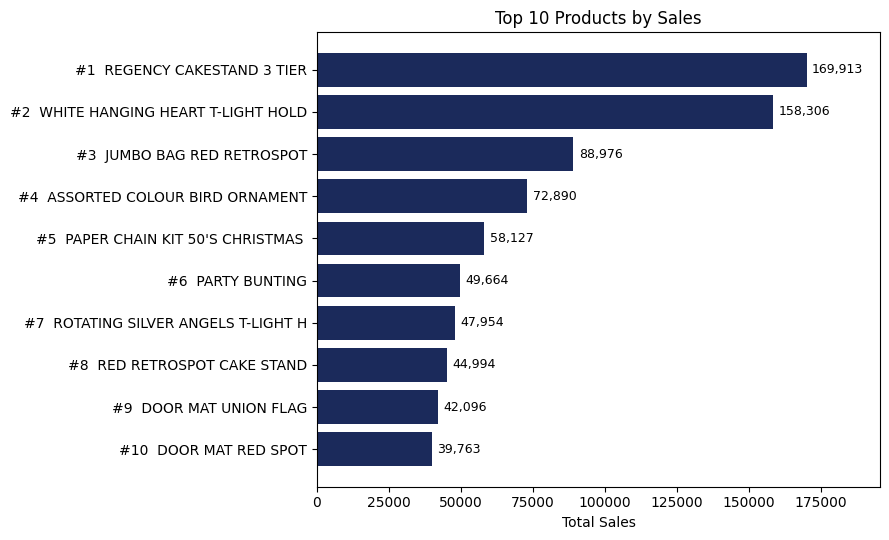

In [11]:
chart_data = top10.sort_values("Total_Sales", ascending=True)     # ascending so the biggest bar plots at the top
labels = [f"#{r}  {d[:32]}" for r, d in zip(chart_data["Rank"], chart_data["Description"])]

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.barh(labels, chart_data["Total_Sales"], color="#1B2A5B")
ax.bar_label(bars, labels=[f"{v:,.0f}" for v in chart_data["Total_Sales"]], padding=4, fontsize=9)

ax.set_xlabel("Total Sales")
ax.set_title("Top 10 Products by Sales")
ax.set_xlim(0, chart_data["Total_Sales"].max() * 1.15)
fig.tight_layout()

fig.savefig(OUTPUT_DIR / "top10_products_chart.png", dpi=150)
plt.show()

## Step 8 — Save the deliverables

Two files, saved into an `output/` folder:

| Deliverable | File |
|---|---|
| Top-10 table | `top10_products.xlsx` (with the exclusion list documented on a second sheet) |
| Chart | `top10_products_chart.png` (already saved in Step 7) |

In [12]:
with pd.ExcelWriter(OUTPUT_DIR / "top10_products.xlsx", engine="openpyxl") as writer:
    top10.to_excel(writer, sheet_name="Top 10 Products", index=False)

    notes = pd.DataFrame({
        "Rule": [
            "Data used",
            "Sale line definition",
            "Non-product codes excluded",
            "Sales value excluded as non-product",
            "Tie-breaking method",
            "Products considered",
        ],
        "Detail": [
            f"{DATA_FILE}, after removing {len(raw) - len(df):,} exact duplicate rows",
            "Quantity x Price > 0, on a normal invoice (not starting with C)",
            ", ".join(sorted(NON_PRODUCT_CODES)),
            f"{excluded['Sales'].sum():,.2f}",
            'pandas .rank(method="min") - ties share the best rank, next rank is skipped',
            f"{len(by_product):,} distinct real products",
        ],
    })
    notes.to_excel(writer, sheet_name="Method Notes", index=False)

    for name, wsdf in [("Top 10 Products", top10), ("Method Notes", notes)]:
        ws = writer.sheets[name]
        ws.freeze_panes = "A2" if name == "Top 10 Products" else "A1"
        for col in ws.columns:
            width = max(len(str(c.value)) if c.value is not None else 0 for c in col[:50])
            ws.column_dimensions[col[0].column_letter].width = min(width + 2, 60)

print("Saved: output/top10_products.xlsx")
print("Saved: output/top10_products_chart.png")
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f"  {f.name:<30} {f.stat().st_size/1024:>8,.0f} KB")

Saved: output/top10_products.xlsx
Saved: output/top10_products_chart.png
  top10_products.xlsx                   6 KB
  top10_products_chart.png             95 KB


## Interview questions — model answers

**1. How do you handle ties?**
First decide *whether* a tie should be possible — that depends on what is being measured (measuring to the cent makes
exact ties rare; rounding to whole currency units makes them common). Then pick a rule and apply it consistently:
`pandas.rank(method=...)` offers `"min"` (tied items share the better rank, the next rank is skipped — like Olympic
medals), `"dense"` (tied items share a rank, nothing is skipped) or `"first"` (ties broken by original row order). This
notebook uses `"min"`, and always checks explicitly whether any tie actually falls at the cutoff (Step 5) rather than
assuming there isn't one.

**2. Why use Top-10 analysis?**
It turns a long, hard-to-read list (here, over 4,200 products) into a short one that is easy to act on: which products to
keep well stocked, which to feature in marketing, which to review with a supplier. It works because sales in most
businesses are concentrated in a few items (Step 6 showed the top 10 alone make up a meaningful share of all product
sales) — a "long tail" of many products each selling a little is much less useful to look at one by one than a short,
ranked list of the biggest contributors.

## Excel method (same task without code)

| Goal | Steps in Excel |
|---|---|
| **Rank products** | Add a column with `=SUMIF(StockCode_range, [this row's code], Sales_range)` next to a list of unique codes, or build a **PivotTable** (Rows = StockCode/Description, Values = Sum of Sales). |
| **Get the top 10 value** | `=LARGE(sales_range, 10)` returns the 10th-biggest value directly, without sorting anything. |
| **Get the top 10 rows** | Sort the PivotTable descending by Sales, or use **Value Filters → Top 10** on the PivotTable field. |
| **Rank with ties shown** | `=RANK.EQ(this_cell, whole_range, 0)` — the 0 means descending. Equal values get the same rank automatically, matching `method="min"` above. |
| **Chart** | Select the top 10 rows → **Insert → Bar Chart** (horizontal bars). Sort the source data descending first, and check "Categories in reverse order" so the biggest bar is on top. |

**Tip:** always filter out non-product rows (postage, discounts, manual entries — see Step 3) *before* building the
PivotTable or using `LARGE`/`RANK.EQ`, or they can quietly sit inside your "top 10".

## Key takeaways

1. **Sorting** orders rows; **ranking** numbers them — ties only become visible when you rank.
2. `.rank(method="min")` is a sensible default for ties: equal values share the best rank, and the next rank is skipped.
3. Always sanity-check the categories you are ranking. Here, some `StockCode` values were shipping charges, fees and
   test entries, not real products — including them would have put "Manual" and "Postage" in the top 10.
4. A short, ranked table plus a horizontal bar chart is the standard, easy-to-read way to present a Top-N result.
5. Document the rules (data used, definitions, exclusions) alongside the result, so anyone can see exactly how "top 10"
   was defined.